# SLEAP Model Analysis
Analysis of centroid + centered instance model predictions for card corner tracking.

**Models used:**
- Centroid: `model_testing_all_camera_angles_sig10.centroid`
- Centered instance: `model_testing_all_camera_angles_sig10-1.instance`

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis")
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

In [2]:
from plot_sleap_model_performance import (
    summarize,
    plot_scoreboard,
    plot_training_curves,
    plot_distance_distribution,
    plot_pck_curves,
    plot_part_accuracy,
    write_summary,
)

In [3]:
CENTROID_MODEL = Path(
    "/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/card_recognitions_sleap/models/model_testing_all_camera_angles_sig10.centroid"
)

INSTANCE_MODEL = Path(
    "/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/card_recognitions_sleap/models/model_testing_all_camera_angles_sig10-1.instance"
)

OUTDIR = PROJECT_ROOT / "outputs" / "all_camera_s10_model_analysis"
OUTDIR.mkdir(parents=True, exist_ok=True)

models = [
    summarize(CENTROID_MODEL),
    summarize(INSTANCE_MODEL),
]

In [4]:
for model in models:
    print(model["name"])
    print("  val mOKS:", model["val"]["mOKS"]["mOKS"])
    print("  val mPCK:", model["val"]["pck_metrics"]["mPCK"])
    print("  val PCK@5:", model["val"]["pck_metrics"]["PCK@5"])
    print("  val avg pixel error:", model["val"]["distance_metrics"]["avg"])
    print()


model_testing_all_camera_angles_sig10.centroid
  val mOKS: 0.999999999461048
  val mPCK: 0.875
  val PCK@5: 0.875
  val avg pixel error: 2.271646709439684e-05

model_testing_all_camera_angles_sig10-1.instance
  val mOKS: 0.2083458574223059
  val mPCK: 0.41666666666666663
  val PCK@5: 0.375
  val avg pixel error: 7.570833518229193



In [5]:
scoreboard_path = plot_scoreboard(models, OUTDIR)
training_path = plot_training_curves(models, OUTDIR)
distance_path = plot_distance_distribution(models, OUTDIR)
pck_path = plot_pck_curves(models, OUTDIR)
part_path = plot_part_accuracy(models, OUTDIR)

report_path = write_summary(
    models,
    OUTDIR,
    [scoreboard_path, training_path, distance_path, pck_path, part_path],
)

print(report_path)

/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/outputs/all_camera_s10_model_analysis/first_model_performance_report.md


scoreboard.png


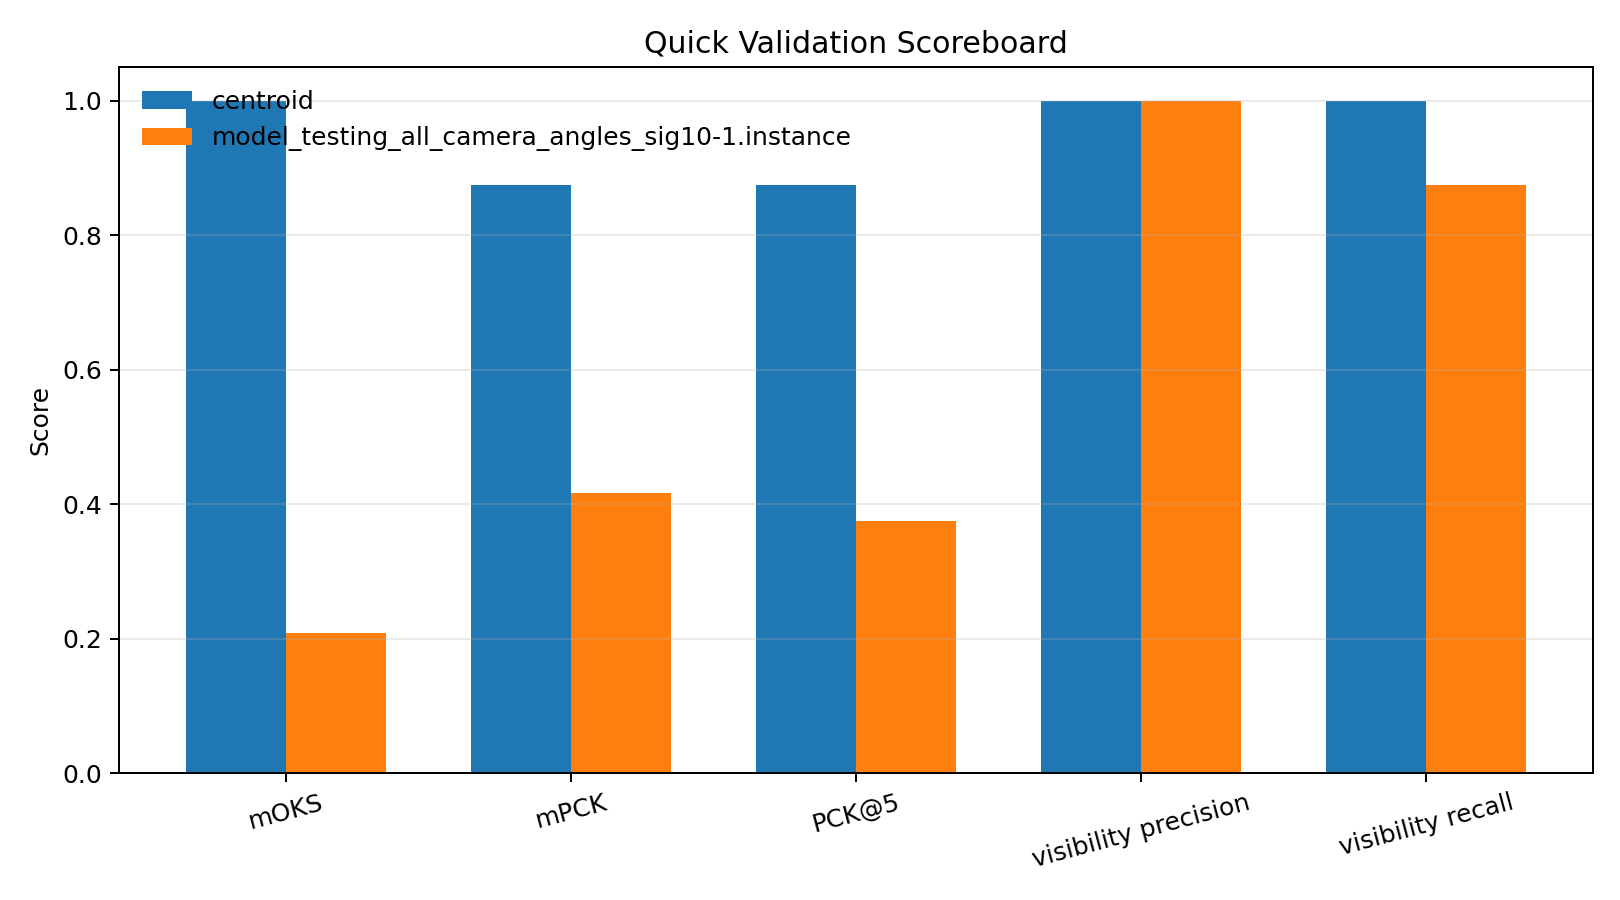

training_curves.png


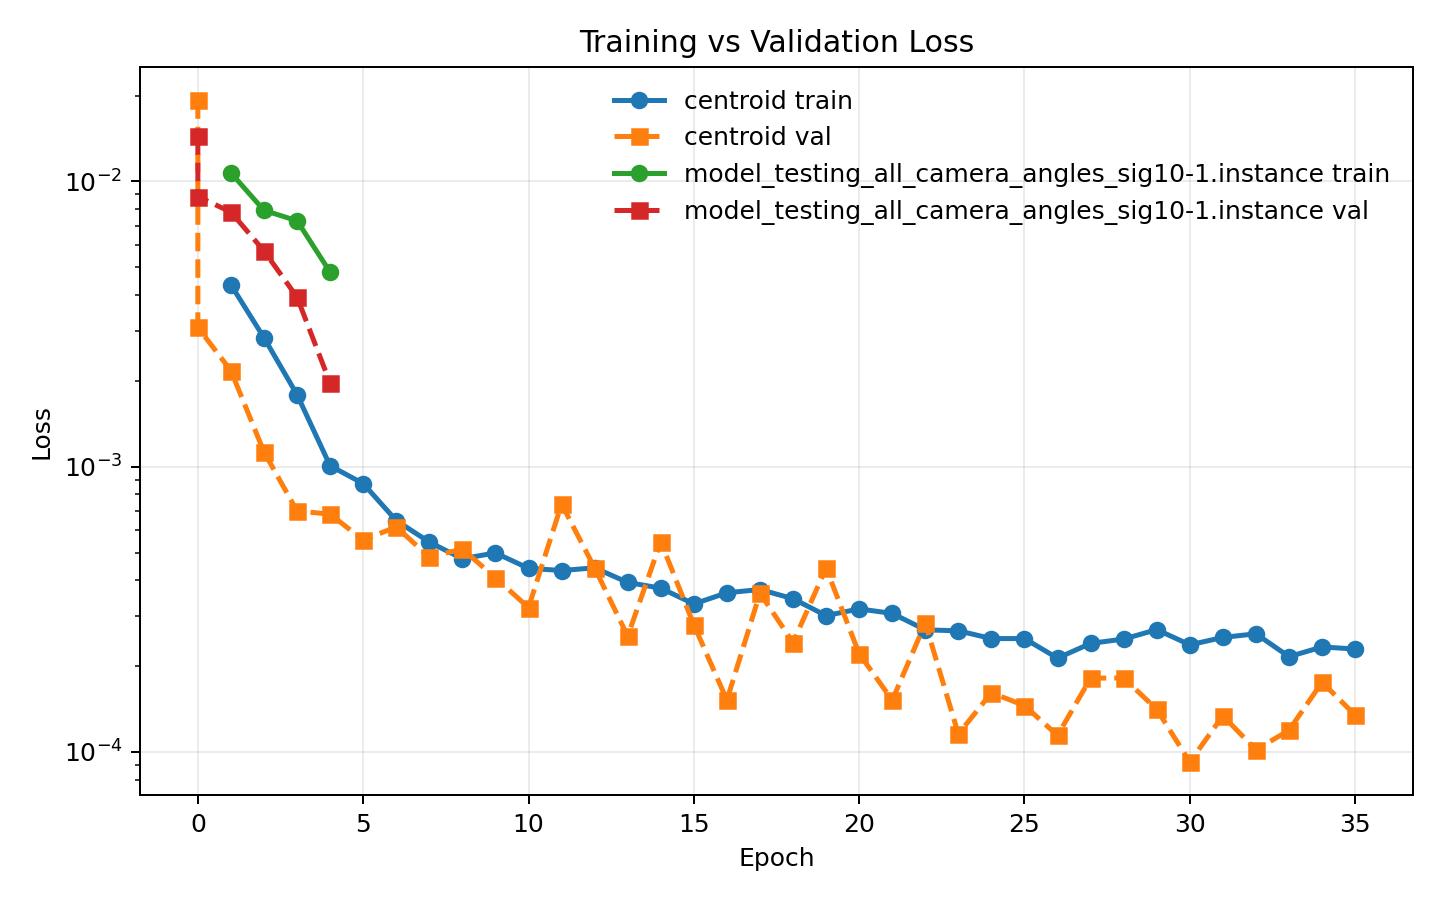

distance_distribution.png


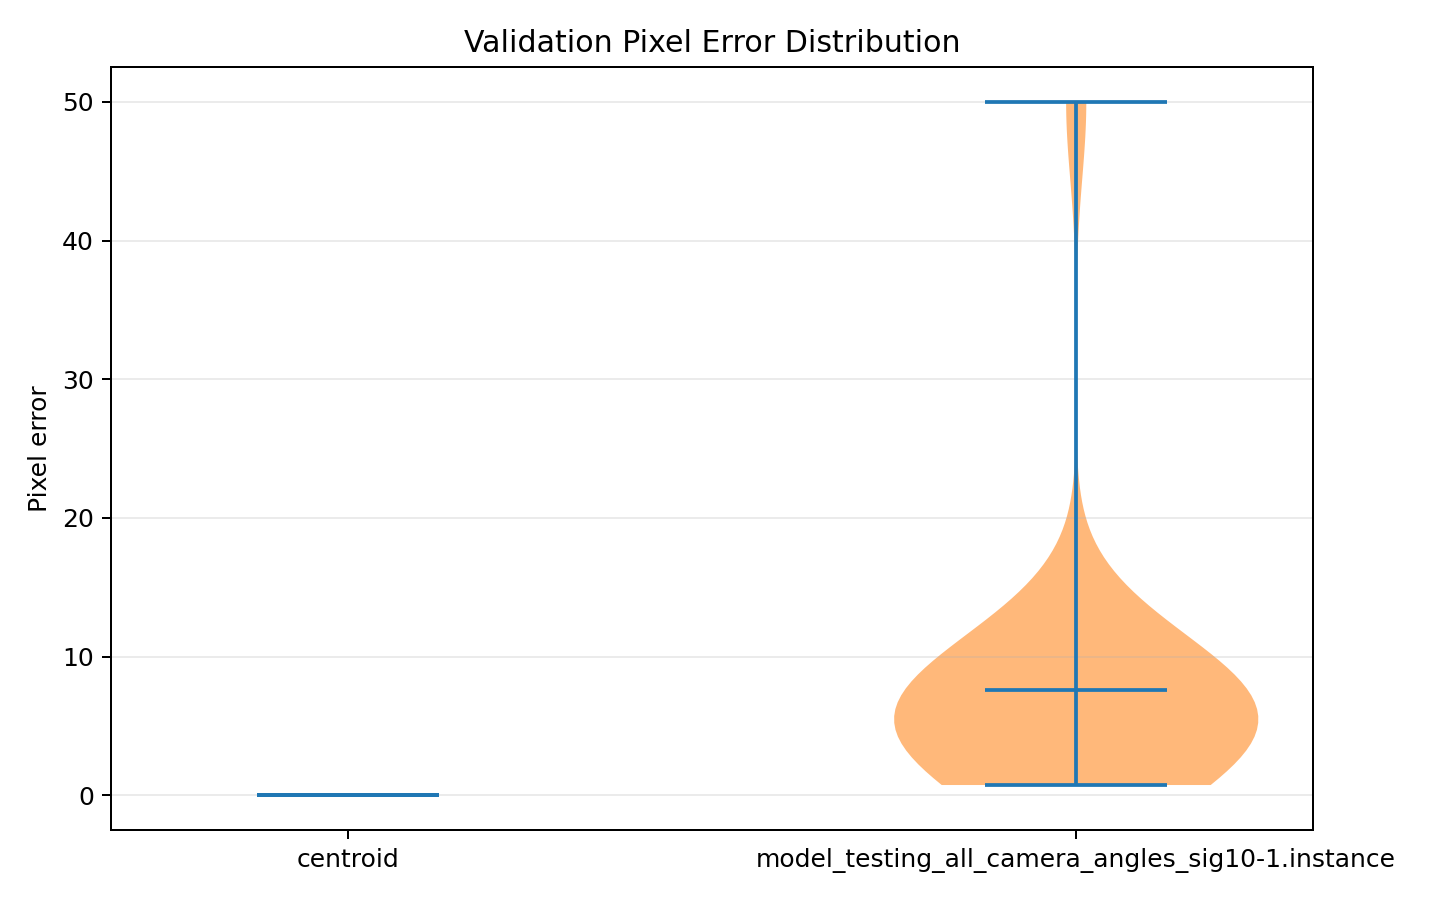

pck_curves.png


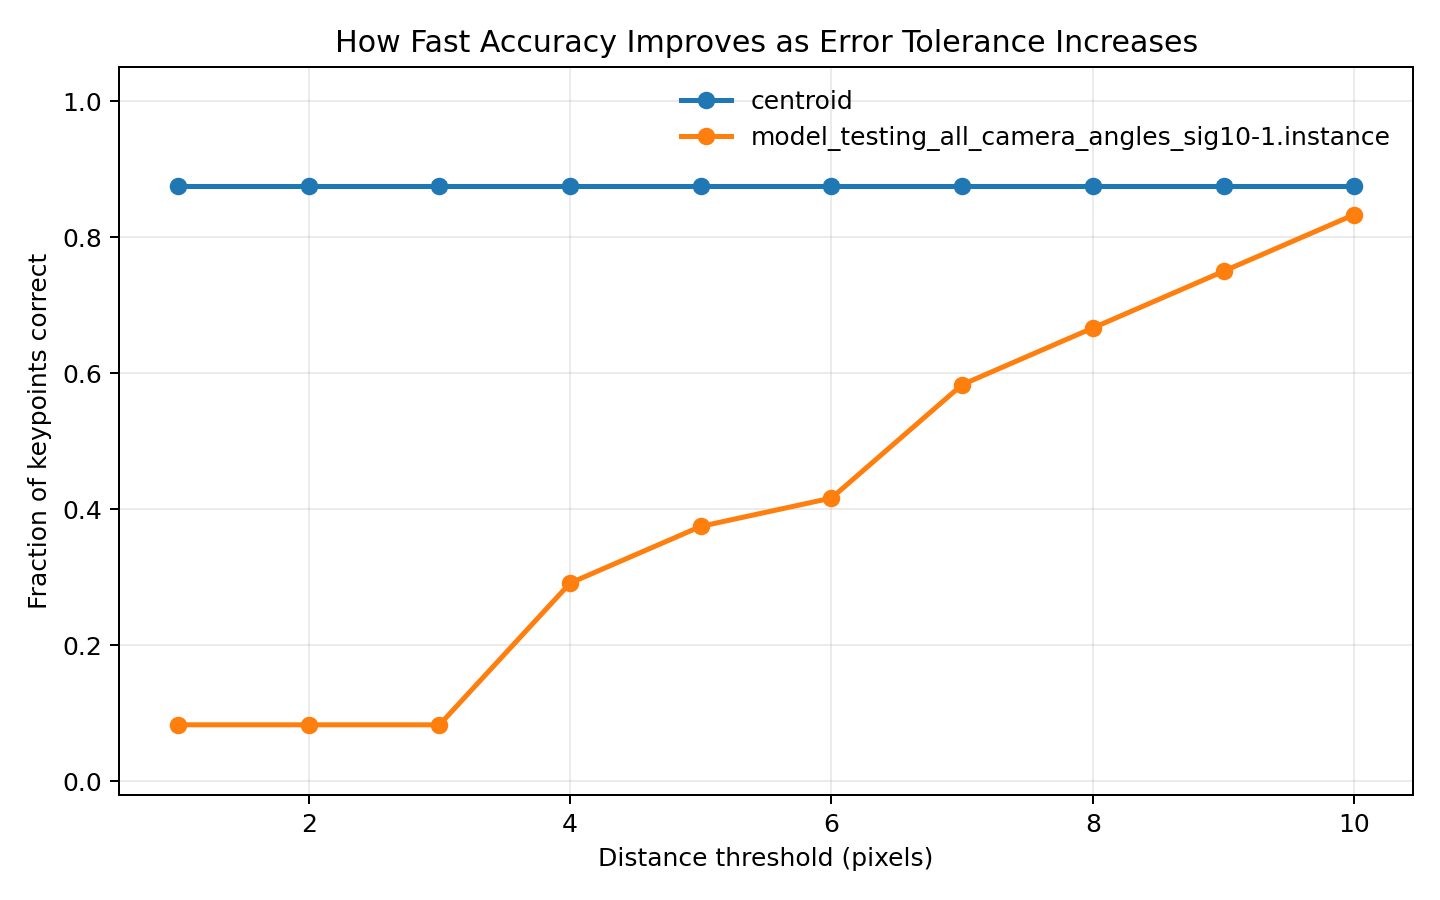

part_accuracy.png


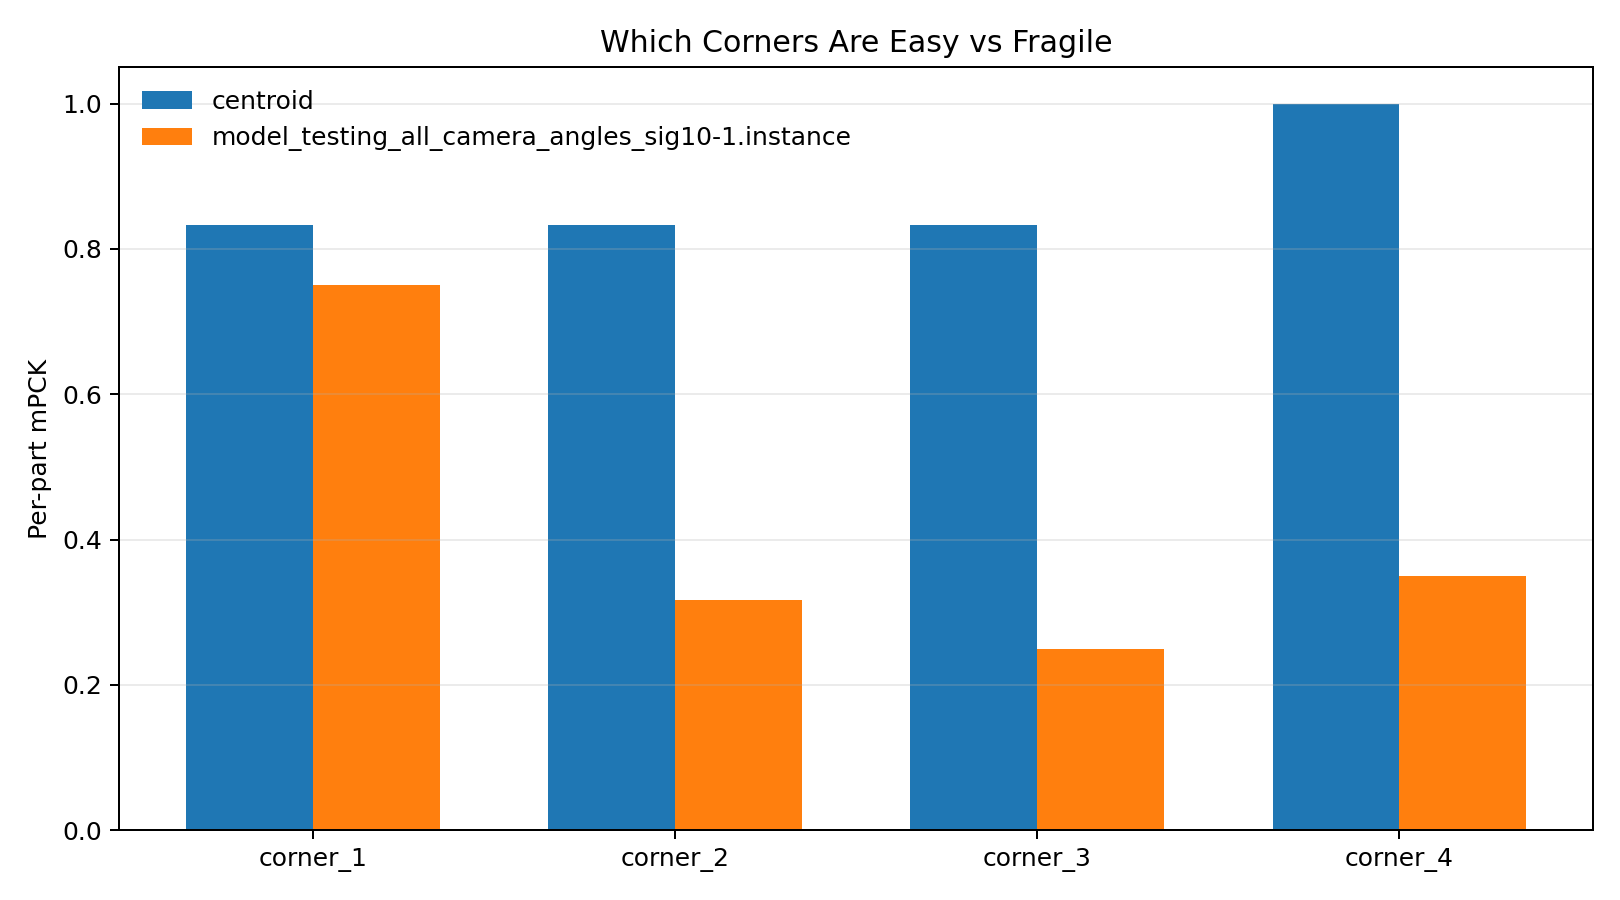

In [6]:
from IPython.display import Image, display

for path in [scoreboard_path, training_path, distance_path, pck_path, part_path]:
    print(path.name)
    display(Image(filename=str(path)))
